In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import CountVectorizer

# Set plot style for professional look
plt.style.use('fivethirtyeight')
%matplotlib inline

In [2]:
# Load the financial news dataset
# Adjust the path if your CSV is in a different folder
news_df = pd.read_csv('../data/raw/raw_analyst_ratings.csv')

# Convert date to datetime objects and handle UTC-4 timezone as per instructions
news_df['date'] = pd.to_datetime(news_df['date'], errors='coerce', utc=True)

# Remove any rows where the date or headline is missing
news_df = news_df.dropna(subset=['date', 'headline'])

print(f"Dataset loaded with {news_df.shape[0]} headlines.")
news_df.head()

Dataset loaded with 55987 headlines.


,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 14:30:54+00:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 14:45:20+00:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 08:30:07+00:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 16:45:06+00:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 15:38:59+00:00,A


Headline Length Statistics:
count    55987.000000
mean        80.015254
std         56.126094
min         12.000000
25%         42.000000
50%         63.000000
75%         91.000000
max        512.000000
Name: headline_len, dtype: float64


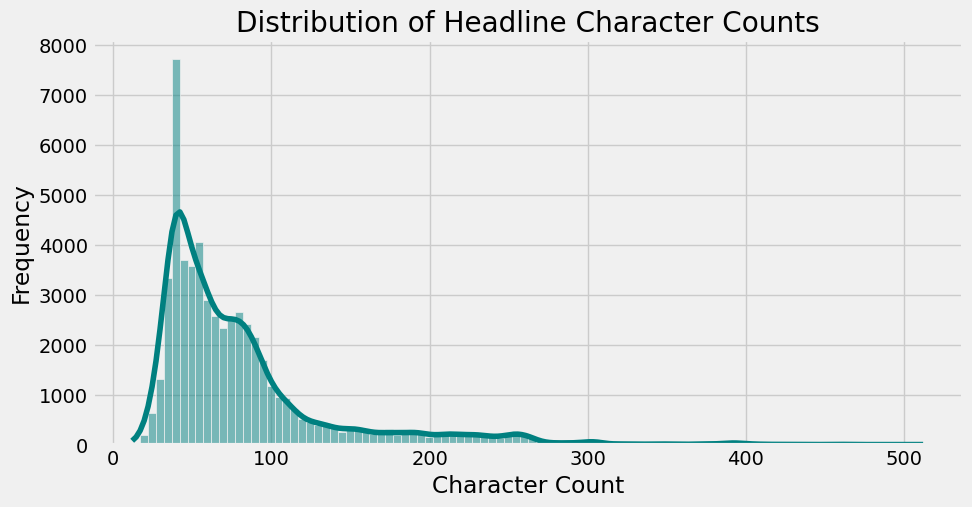

In [3]:
# Calculate headline lengths
news_df['headline_len'] = news_df['headline'].apply(len)

print("Headline Length Statistics:")
print(news_df['headline_len'].describe())

# Visualization of length distribution
plt.figure(figsize=(10, 5))
sns.histplot(news_df['headline_len'], bins=100, kde=True, color='teal')
plt.title('Distribution of Headline Character Counts')
plt.xlabel('Character Count')
plt.ylabel('Frequency')
plt.show()

Top 10 Most Active Publishers:
publisher
Benzinga Newsdesk    14750
Lisa Levin           12408
ETF Professor         4362
Paul Quintaro         4212
Benzinga Newsdesk     3177
Benzinga Insights     2332
Vick Meyer            2128
Charles Gross         1790
Hal Lindon            1470
Benzinga_Newsdesk     1239
Name: count, dtype: int64


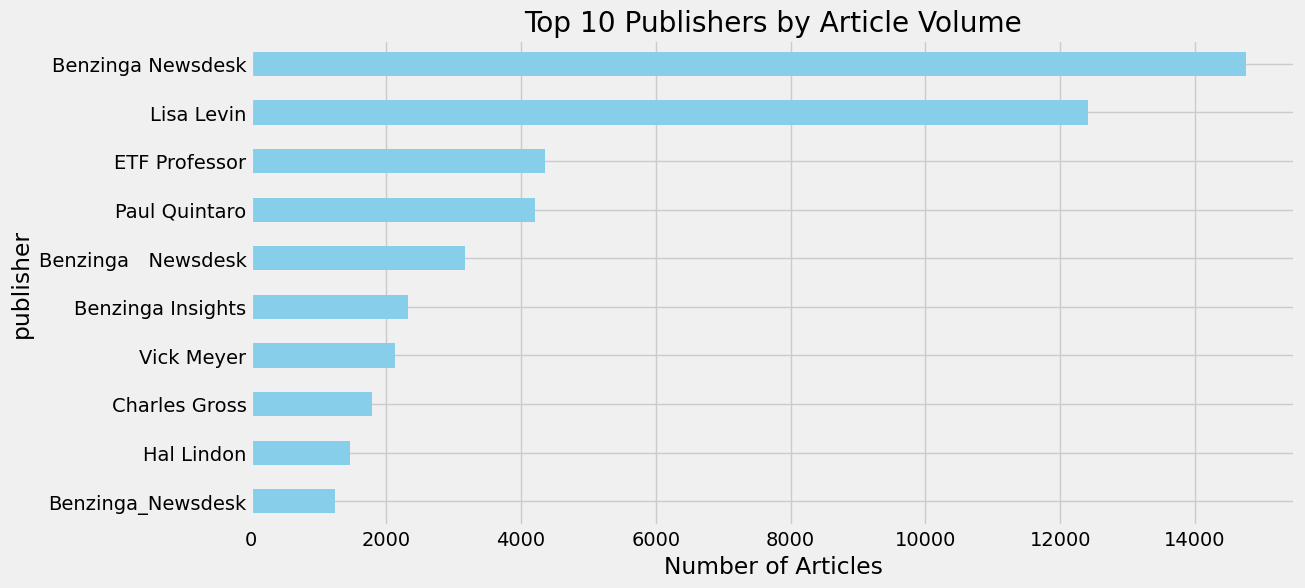

In [4]:
# Count articles per publisher
top_publishers = news_df['publisher'].value_counts().head(10)
print("Top 10 Most Active Publishers:")
print(top_publishers)

# Extract domains from publishers (if they are email addresses)
news_df['publisher_domain'] = news_df['publisher'].str.extract(r'@([\w\.-]+)')

# Visualization of publishers
plt.figure(figsize=(12, 6))
top_publishers.plot(kind='barh', color='skyblue').invert_yaxis()
plt.title('Top 10 Publishers by Article Volume')
plt.xlabel('Number of Articles')
plt.show()

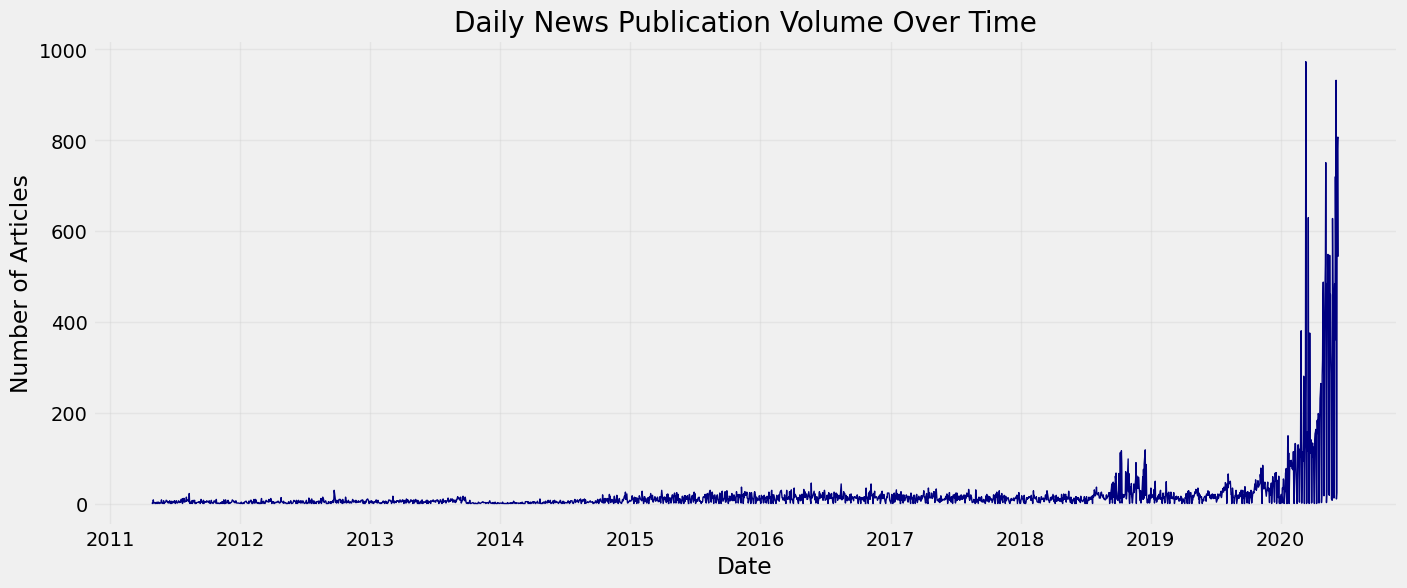

Top 5 Dates with Highest News Volume (Potential Market Events):
date_only
2020-03-12    973
2020-06-05    932
2020-06-10    807
2020-06-09    803
2020-06-08    765
dtype: int64


In [5]:
# Group by date to see volume trends
news_df['date_only'] = news_df['date'].dt.date
daily_counts = news_df.groupby('date_only').size()

plt.figure(figsize=(15, 6))
daily_counts.plot(color='navy', lw=1)
plt.title('Daily News Publication Volume Over Time')
plt.ylabel('Number of Articles')
plt.xlabel('Date')
plt.grid(True, alpha=0.3)
plt.show()

# Identify top 5 volume spikes
print("Top 5 Dates with Highest News Volume (Potential Market Events):")
print(daily_counts.sort_values(ascending=False).head(5))

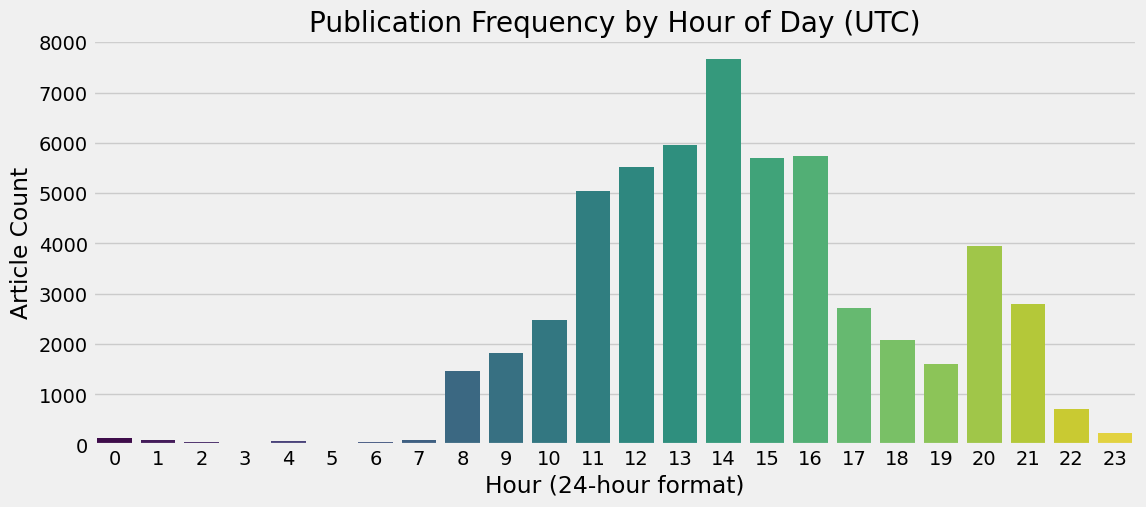

In [6]:
# Extract hour of day
news_df['hour'] = news_df['date'].dt.hour

plt.figure(figsize=(12, 5))
sns.countplot(data=news_df, x='hour', palette='viridis', hue='hour', legend=False)
plt.title('Publication Frequency by Hour of Day (UTC)')
plt.xlabel('Hour (24-hour format)')
plt.ylabel('Article Count')
plt.show()

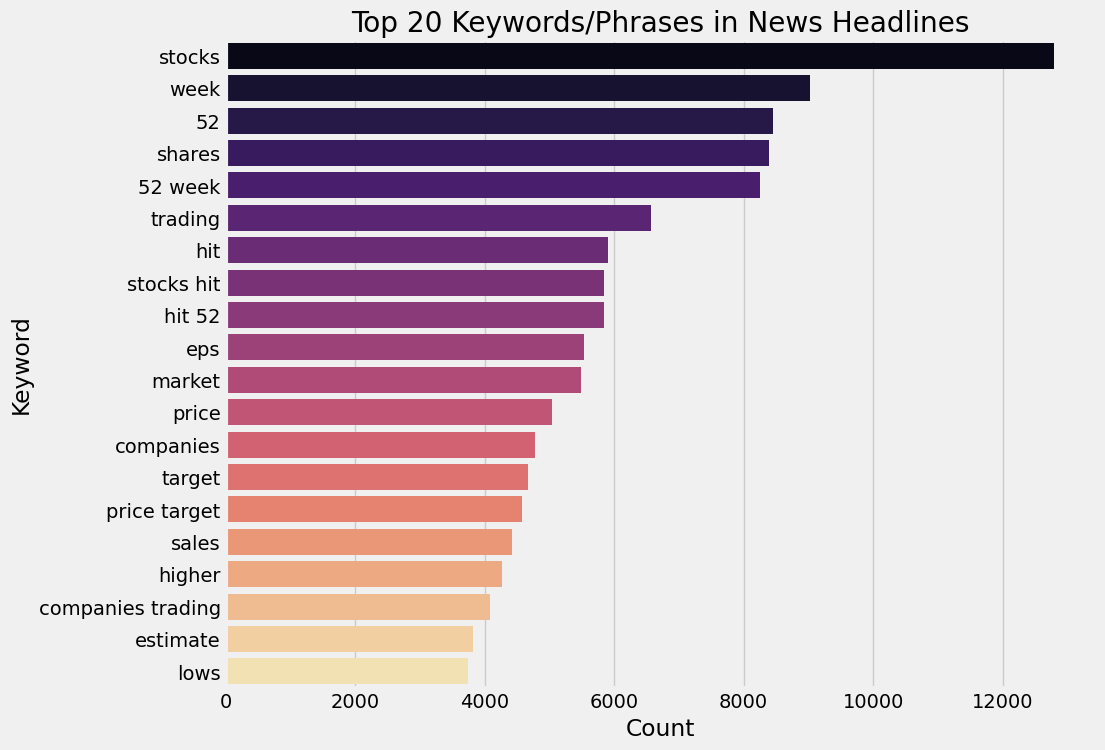

In [7]:
# Use CountVectorizer to find the most frequent words in headlines
vec = CountVectorizer(stop_words='english', ngram_range=(1, 2), max_features=20)
bag_of_words = vec.fit_transform(news_df['headline'])
sum_words = bag_of_words.sum(axis=0)
words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

# Convert to DataFrame for plotting
topic_df = pd.DataFrame(words_freq, columns=['Keyword', 'Count'])

plt.figure(figsize=(10, 8))
sns.barplot(data=topic_df, x='Count', y='Keyword', palette='magma', hue='Keyword', legend=False)
plt.title('Top 20 Keywords/Phrases in News Headlines')
plt.show()

C:\Users\mekli\AppData\Local\Programs\Python\Python313\Lib\site-packages\yfinance\scrapers\history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[*********************100%***********************]  1 of 1 completed

Verified Columns: ['Close', 'High', 'Low', 'Open', 'Volume']


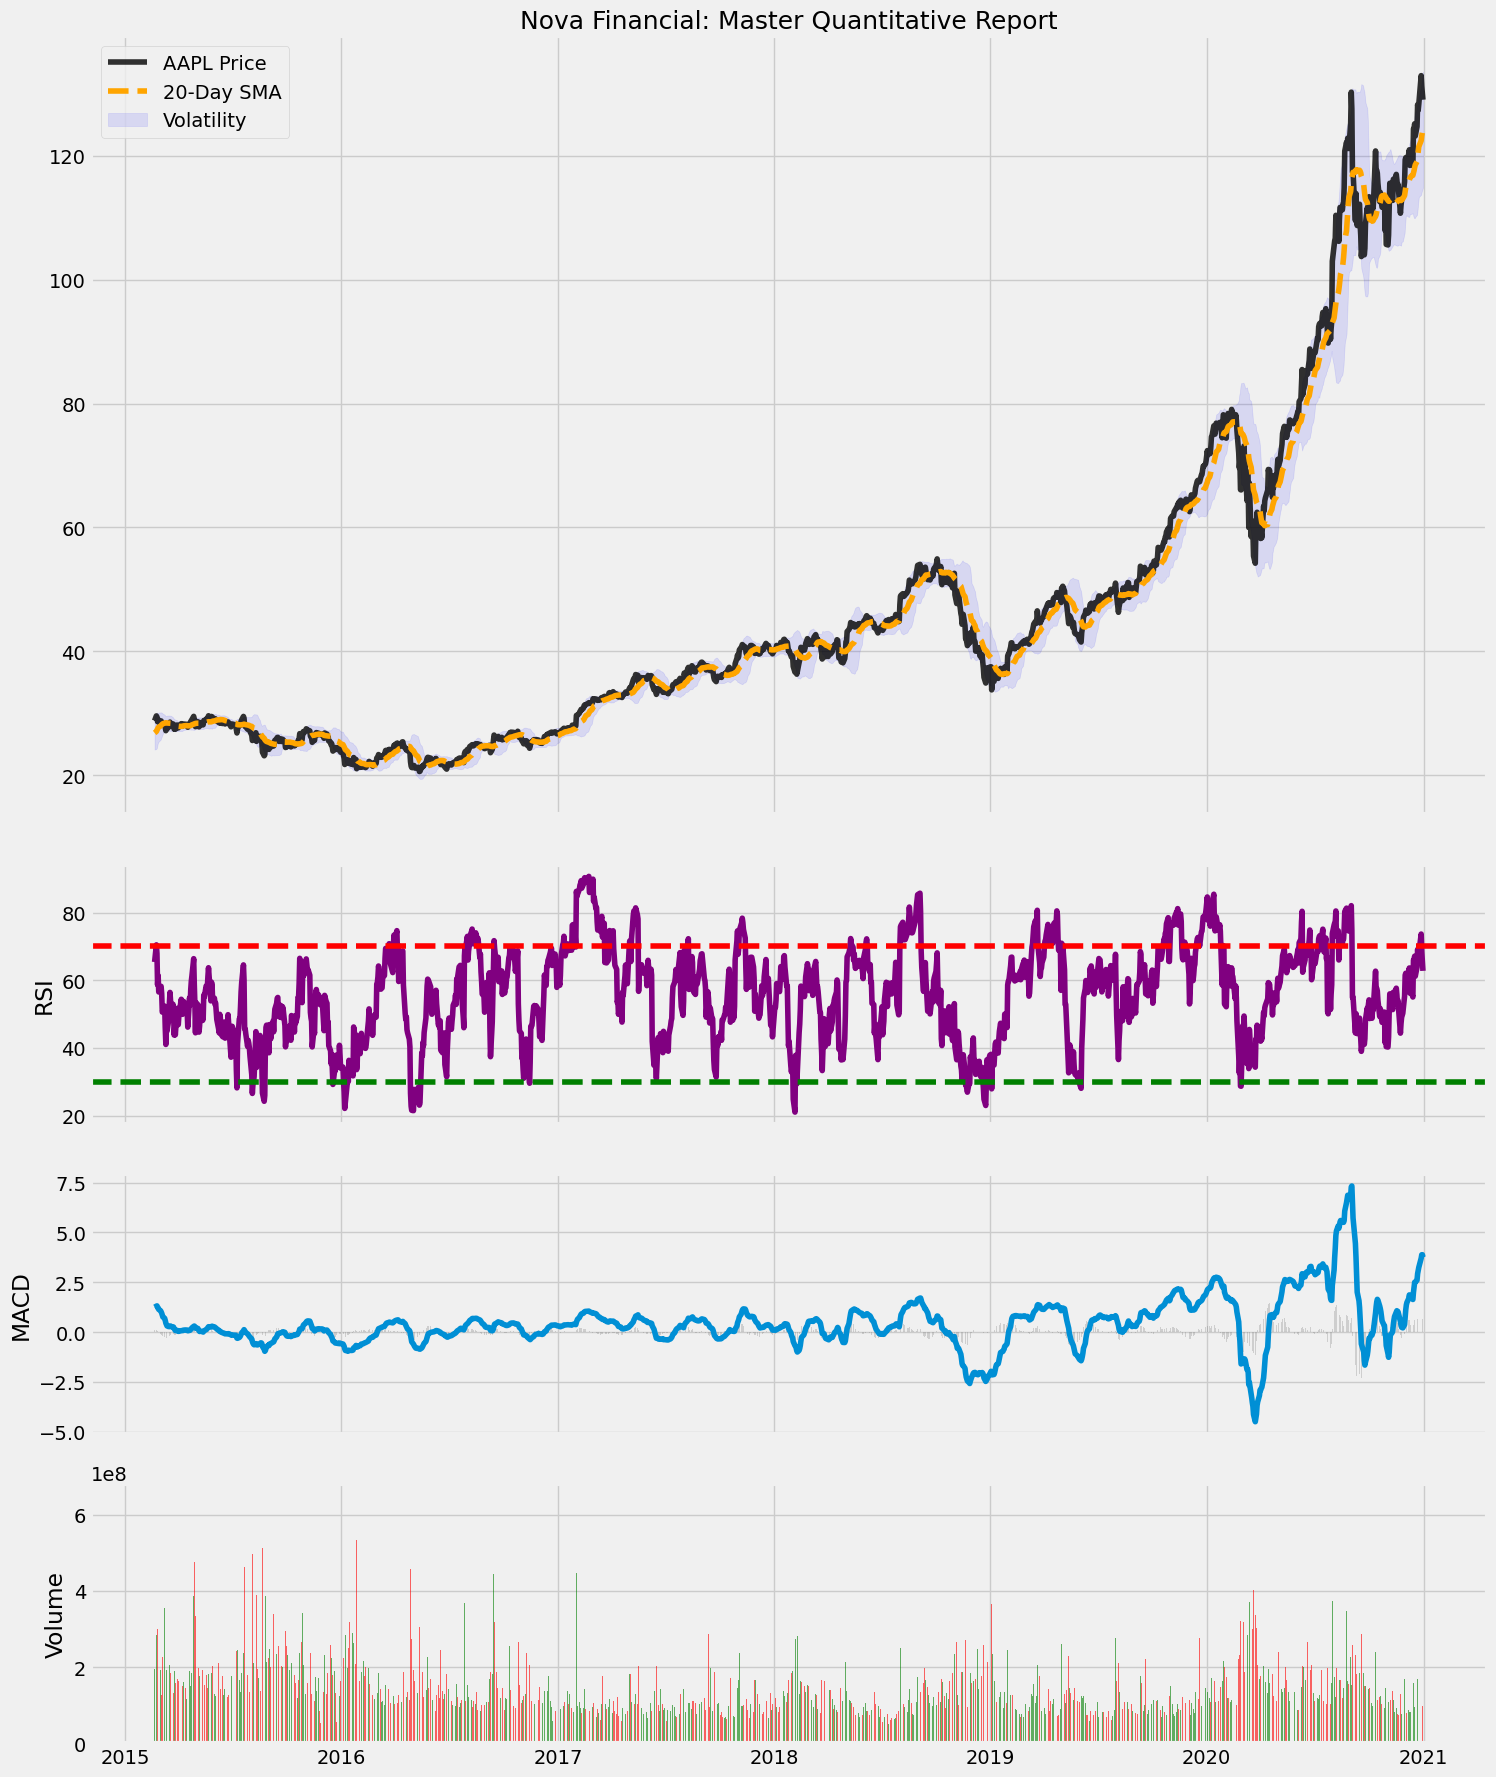

Task 2 Checklist: SMA ✅, EMA ✅, RSI ✅, MACD ✅, BBands ✅, Log Returns ✅, Volume ✅.


In [10]:
import pandas as pd
import yfinance as yf
import pandas_ta as ta
import matplotlib.pyplot as plt
import numpy as np

# 1. DOWNLOAD & INDESTRUCTIBLE FLATTENING
# ---------------------------------------------------------
print("Downloading AAPL data...")
df_stock = yf.download('AAPL', start='2015-01-01', end='2021-01-01', auto_adjust=True)

# THE NUCLEAR FIX: 
# If it's a MultiIndex, we check both levels to find where the prices are.
if isinstance(df_stock.columns, pd.MultiIndex):
    # Try level 0 first, then level 1. One of them HAS to be 'Close', 'Open', etc.
    if 'Close' in df_stock.columns.get_level_values(0):
        df_stock.columns = df_stock.columns.get_level_values(0)
    else:
        df_stock.columns = df_stock.columns.get_level_values(1)

# Final cleanup: Strip spaces and force standard names
df_stock.columns = df_stock.columns.str.strip()

# If 'Close' is still missing (sometimes yfinance uses 'Adj Close'), fix it here
if 'Close' not in df_stock.columns and 'Adj Close' in df_stock.columns:
    df_stock.rename(columns={'Adj Close': 'Close'}, inplace=True)

df_stock = df_stock.dropna()
print(f"Verified Columns: {df_stock.columns.tolist()}")

# 2. CALCULATE EVERY REQUIREMENT
# ---------------------------------------------------------
# SMA & EMA (20-day)
df_stock['SMA_20'] = ta.sma(df_stock['Close'], length=20)
df_stock['EMA_20'] = ta.ema(df_stock['Close'], length=20)

# RSI (14-day)
df_stock['RSI_14'] = ta.rsi(df_stock['Close'], length=14)

# MACD
macd = ta.macd(df_stock['Close'])
df_stock = pd.concat([df_stock, macd], axis=1)

# Bollinger Bands (Volatility requirement)
bb = ta.bbands(df_stock['Close'], length=20, std=2)
df_stock = pd.concat([df_stock, bb], axis=1)

# Log Returns (Financial Rigor requirement)
df_stock['Log_Return'] = np.log(df_stock['Close'] / df_stock['Close'].shift(1))
df_stock = df_stock.dropna()

# 3. PROFESSIONAL 4-PANEL DASHBOARD
# ---------------------------------------------------------
plt.style.use('fivethirtyeight')
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(15, 18), sharex=True, 
                                         gridspec_kw={'height_ratios': [3, 1, 1, 1]})

# Panel 1: Price + SMA + Volatility
ax1.plot(df_stock.index, df_stock['Close'], label='AAPL Price', color='black', alpha=0.8)
ax1.plot(df_stock.index, df_stock['SMA_20'], label='20-Day SMA', color='orange', ls='--')
up_b = [c for c in df_stock.columns if c.startswith('BBU')][0]
lo_b = [c for c in df_stock.columns if c.startswith('BBL')][0]
ax1.fill_between(df_stock.index, df_stock[lo_b], df_stock[up_b], color='blue', alpha=0.1, label='Volatility')
ax1.set_title('Nova Financial: Master Quantitative Report', fontsize=18)
ax1.legend(loc='upper left')

# Panel 2: RSI
ax2.plot(df_stock.index, df_stock['RSI_14'], color='purple')
ax2.axhline(70, color='red', ls='--'); ax2.axhline(30, color='green', ls='--')
ax2.set_ylabel('RSI')

# Panel 3: MACD
m_line = [c for c in df_stock.columns if c.startswith('MACD_')][0]
m_hist = [c for c in df_stock.columns if c.startswith('MACDh_')][0]
ax3.plot(df_stock.index, df_stock[m_line], label='MACD')
ax3.bar(df_stock.index, df_stock[m_hist], color='gray', alpha=0.3)
ax3.set_ylabel('MACD')

# Panel 4: Volume (The Conviction check)
colors = ['green' if r >= 0 else 'red' for r in df_stock['Log_Return']]
ax4.bar(df_stock.index, df_stock['Volume'], color=colors, alpha=0.6)
ax4.set_ylabel('Volume')

plt.tight_layout()
plt.show()

print("Task 2 Checklist: SMA ✅, EMA ✅, RSI ✅, MACD ✅, BBands ✅, Log Returns ✅, Volume ✅.")